In [ ]:
pip install qiskit

In [ ]:
!pip install pylatexenc

{'1': 2048}


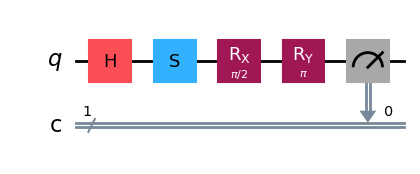

In [ ]:
from qiskit import QuantumCircuit
from qiskit.providers.basic_provider import BasicProvider
from qiskit.visualization import plot_histogram, circuit_drawer
import pylatexenc
from math import pi

# Criação do circuito com 1 qubit e 1 registrador clássico
qc = QuantumCircuit(1,1)

# Aplicando portas de rotação
qc.h(0)
qc.s(0)
qc.rx(pi/2, 0)
qc.ry(pi,0)


# Medição
qc.measure(0,0)
# Simulador básico
backend = BasicProvider().get_backend("basic_simulator")
result = backend.run(qc, shots=2048).result()
counts = result.get_counts()

print(counts)
qc.draw("mpl")

{'10 00': 508, '01 00': 526, '11 00': 494, '00 00': 520}


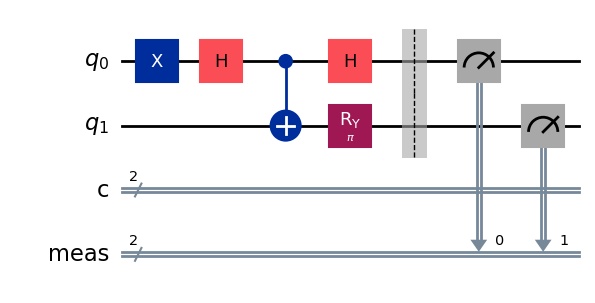

In [ ]:
# Criação do circuito com 1 qubit e 1 registrador clássico
qc = QuantumCircuit(2,2)

# Aplicando portas de rotação
qc.x(0)
qc.h(0)
qc.cx(0,1)
qc.h(0)
qc.ry(pi,1)


# Medição
#qc.measure_all()
qc.measure_all()
# Simulador básico
backend = BasicProvider().get_backend("basic_simulator")
result = backend.run(qc, shots=2048).result()
counts = result.get_counts()

print(counts)
qc.draw("mpl")

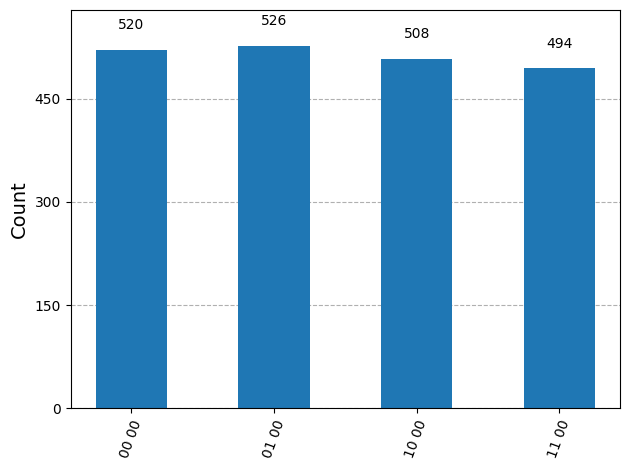

In [ ]:
plot_histogram(counts)

{'011': 525, '000': 463, '001': 556, '010': 504}


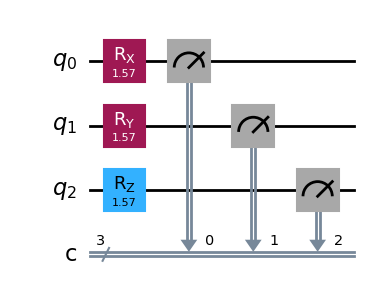

In [ ]:
from qiskit import QuantumCircuit
from qiskit.providers.basic_provider import BasicProvider
from qiskit.visualization import plot_histogram, circuit_drawer
import pylatexenc

# Criação do circuito com 1 qubit e 1 registrador clássico
qc = QuantumCircuit(3,3)

# Aplicando portas de rotação
qc.rx(3.1415/2, 0)   # Rotação de 90° em torno do eixo X
qc.ry(3.1415/2, 1)   # Rotação de 90° em torno do eixo Y
qc.rz(3.1415/2, 2)   # Rotação de 90° em torno do eixo Z

# Medição
#qc.measure_all()
qc.measure([0,1,2],[0,1,2])
# Simulador básico
backend = BasicProvider().get_backend("basic_simulator")
result = backend.run(qc, shots=2048).result()
counts = result.get_counts()

print(counts)
qc.draw("mpl")  # visualização mais bonita


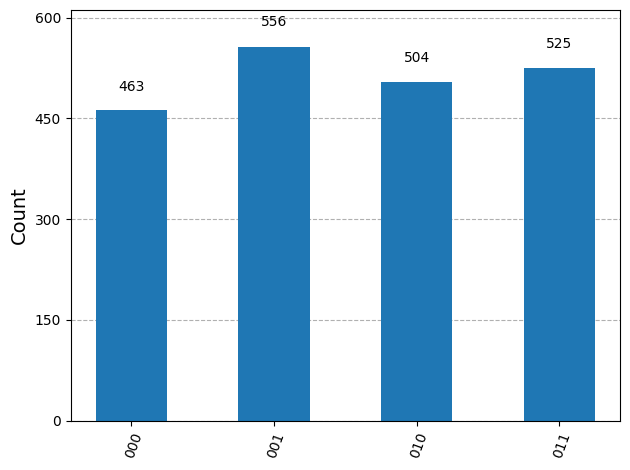

In [ ]:
plot_histogram(counts)


{'00': 1004, '11': 1044}


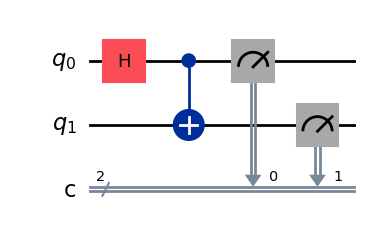

In [ ]:
from qiskit import QuantumCircuit
from qiskit.providers.basic_provider import BasicProvider
from qiskit.visualization import plot_histogram, circuit_drawer
import pylatexenc

qc = QuantumCircuit(2,2)

qc.h(0)      # cria superposição no qubit de controle
qc.cx(0,1)   # CNOT: se controle = 1 → inverte o alvo
qc.measure([0,1],[0,1])

backend = BasicProvider().get_backend("basic_simulator")
result = backend.run(qc, shots=2048).result()
counts = result.get_counts()

print(counts)
qc.draw("mpl")


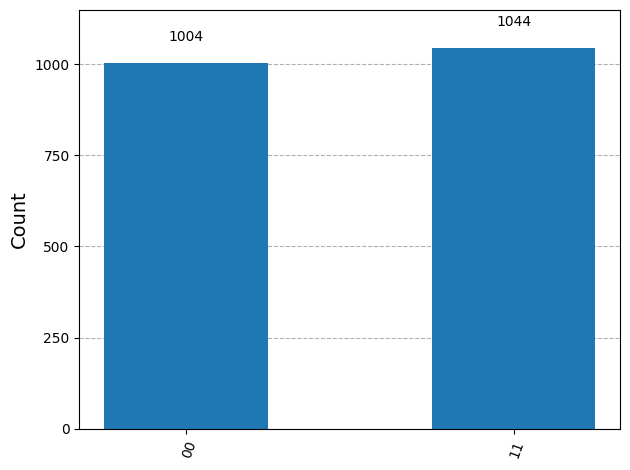

In [ ]:
plot_histogram(counts)

{'001': 509, '111': 525, '000': 524, '010': 490}


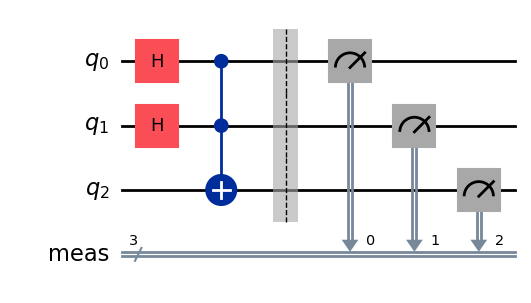

In [ ]:
from qiskit import QuantumCircuit
from qiskit.providers.basic_provider import BasicProvider
from qiskit.visualization import plot_histogram
import pylatexenc

qc = QuantumCircuit(3)

qc.h(0)
qc.h(1)
qc.ccx(0,1,2)   # Toffoli: X no qubit 2 se (q0,q1) = (1,1)
qc.measure_all()

backend = BasicProvider().get_backend("basic_simulator")
result = backend.run(qc, shots=2048).result()
counts = result.get_counts()

print(counts)
qc.draw("mpl")


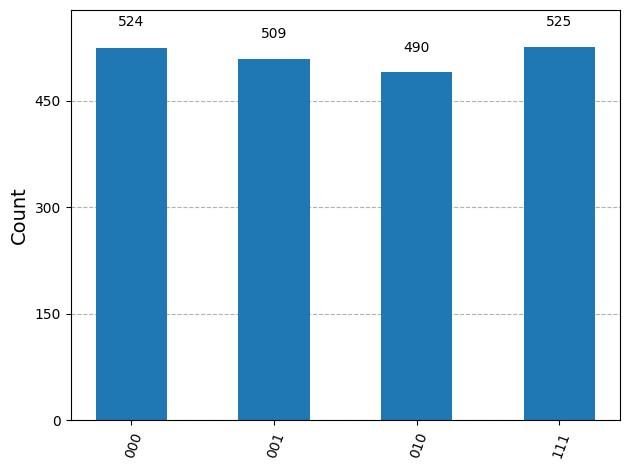

In [ ]:
plot_histogram(counts)

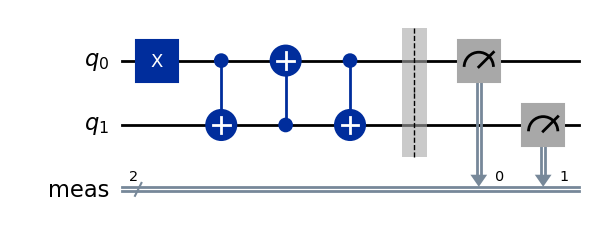

In [ ]:
from qiskit import QuantumCircuit
from qiskit.providers.basic_provider import BasicProvider
from qiskit.visualization import plot_histogram, circuit_drawer
import pylatexenc

qc = QuantumCircuit(2)

qc.x(0)      # cria superposição no qubit de controle
qc.cx(0,1)   # CNOT: se controle = 1 → inverte o alvo
qc.cx(1,0)
qc.cx(0,1)
qc.measure_all()

backend = BasicProvider().get_backend("basic_simulator")
result = backend.run(qc, shots=2048).result()
counts = result.get_counts()

qc.draw("mpl")


{'10 00': 2048}


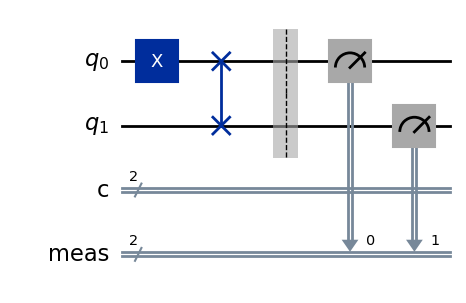

In [ ]:
from qiskit import QuantumCircuit
from qiskit.providers.basic_provider import BasicProvider
from qiskit.visualization import plot_histogram
import pylatexenc

qc = QuantumCircuit(2,2)

qc.x(0)       # Inicializa o primeiro qubit em |1>
qc.swap(0,1)  # Troca o estado entre os dois qubits
qc.measure_all()

backend = BasicProvider().get_backend("basic_simulator")
result = backend.run(qc, shots=2048).result()
counts = result.get_counts()

print(counts)
qc.draw("mpl")

# Algoritmo de Deutsch

Função constante: {'0': 1024}


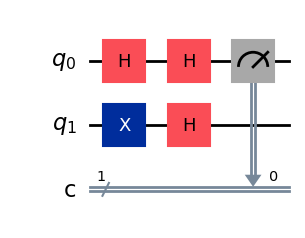

In [ ]:
from qiskit import QuantumCircuit
from qiskit.providers.basic_provider import BasicProvider
from qiskit.visualization import plot_histogram
import pylatexenc

qc = QuantumCircuit(2,1)

# Prepara |x=0> e |y=1>
qc.x(1)
qc.h([0,1])

# Uf constante (identidade)
# nenhuma operação adicional

# Desfaz a superposição e mede x
qc.h(0)
qc.measure(0,0)

backend = BasicProvider().get_backend("basic_simulator")
result = backend.run(qc, shots=1024).result()
counts = result.get_counts()

print("Função constante:", counts)
qc.draw("mpl")

Função balanceada: {'1': 1024}


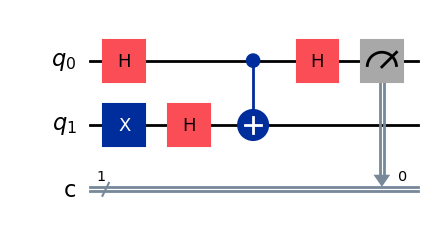

In [ ]:
qc = QuantumCircuit(2,1)

qc.x(1)
qc.h([0,1])

# Uf balanceada
qc.cx(0,1)

qc.h(0)
qc.measure(0,0)

backend = BasicProvider().get_backend("basic_simulator")
result = backend.run(qc, shots=1024).result()
counts = result.get_counts()

print("Função balanceada:", counts)
qc.draw("mpl")
